<center>

# **PA4.1: Decision Trees and Ensemble Methods**

### **Total : 100 marks**

</center>

Name: Muhammad Anas Naveed

Roll Number: 28100045


## Instructions

- Follow along with the notebook, filling out the necessary code where instructed.

- <span style="color: red;">Make sure to run all cells for credit.</span>

- <span style="color: red;">Do not remove any pre-written code (unless explicitly mentioned in the cell that you are allowed to do so).</span>

- <span style="color: red;">You must attempt all parts.</span>

## Submission Guidelines

You are to submit a zip file containing the following files:

1. This juptyer notebook. `<roll_number>_S<section_number>_PA4.ipynb`
2. Python file of the juptyer notebook. `<roll_number>_S<section_number>_PA4.py`

For example if I am from S1 and my roll number is 28100131, my files would be named `28100131_S1_PA4.ipynb` and `28100131_S1_PA4.py`

IMPORTANT: **zip the files.**


## Question 1: Brief Context

In this question, you will implement a **binary decision tree classifier** from scratch and apply it to the classic **Titanic** dataset. The target is `survived` (1 = survived, 0 = did not survive). You will: (i) prepare the data, (ii) split into train/test, (iii) implement and train your own tree, and (iv) evaluate performance with standard metrics. 

You **must** implement the decision tree **from scratch** (no scikit-learn tree). You may use `numpy`, `pandas`, `seaborn`, `matplotlib`, and `sklearn` **only** for utilities like `train_test_split` and metrics.


## Part A - Setup & Imports
**Guidance:** Use standard scientific Python tools. If a package is missing, install it in your environment before running the notebook.

- You will likely need: `numpy`, `pandas`, `seaborn`, `matplotlib`
- Utilities allowed from scikit-learn: `train_test_split`, `classification_report`, `confusion_matrix`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`
- **Do not** use scikit-learn decision tree implementations.

In [35]:
# TODO: Import the scientific Python stack you'll need.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


## Part B - Data Loading & Initial Glance (5 Marks)

**Tasks:**
1. Load the Titanic dataset from `seaborn` as `df`.  
2. Display the shape and first few rows.  
3. In the markdown cell below, briefly note which columns you expect to be useful for prediction and any columns you plan to exclude (IDs, duplicates, very sparse/free-text).  

---

### What are the features? 

- **Some potentially useful features:**  
  - `pclass`: Proxy for socioeconomic status.  
  - `sex`: Strong historical correlation with survival.  
  - `age`: Important demographic factor.  
  - `fare`: Reflects ticket cost and class.  
  - `embarked`: Port of embarkation, may indicate regional or class differences.  
  - `sibsp`: Number of siblings/spouses aboard, gives family context.  
  - `parch`: Number of parents/children aboard, captures family connections.  

- **Exclude these features: (duplicates, engineered, or sparse)**  
  - `class`, `who`, `adult_male`, `alone`: Engineered or redundant.  
  - `embark_town`: Duplicate of `embarked`.  
  - `alive`: Text duplicate of target `survived`.  
  - `deck`: Too sparse (many missing values).  


In [36]:
# explore dataset
df = sns.load_dataset("titanic")
print(df.size)
print(df.shape)
print(df.head())
new_df = df.drop(columns=["class","who", "adult_male","alone","embark_town","alive","deck"])
new_df.head()


13365
(891, 15)
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


,survived,pclass,sex,age,sibsp,parch,fare,embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


### Identify features that might have low predictive value. For each feature you mention, provide reasoning for why it may not be useful.

sibsp: It doesnt seem useful because the same having siblings or not having siblings is giving different label at the end even when two instances have the same value.
parch: All of them(at least in the first 5 rows) are 0 but the label keeps on changing thus have little or no effect on the end result

## Part C - Data Tidying & Encoding
We tackle Part C in two simple passes so it is easier to follow: first, look at basic plots to see which columns clearly link to survival (strong correlations); second, keep only those useful columns and turn everything into numbers.

**Plain-language plan:**
1. **Part C.1 — Explore:** Plot survival rate for a few categorical columns (class, sex, embark, etc.). Circle or note the ones where the bars differ a lot — that means the feature carries a pattern your tree can learn.
2. **Part C.2 — Prep:** Based on those observations, build your feature matrix: keep pattern-rich columns, drop weak/noisy ones, clean missing values, and one-hot encode.

**Tips:**
- The target is `survived` (1 = yes, 0 = no). Keep it as the last column in any training dataframe.
- When you justify a feature, mention what you saw in the plot (e.g., "pclass=1 had much higher survival, so I kept it").
- Simple cleaning is fine: drop or fill NaNs with medians/modes, then encode categoricals with `pd.get_dummies`.
- Always keep `X` (features) and `y` (target) aligned.

**Deliverables:**
- Part C.1 plots + a short note on which columns look important.
- Part C.2 shapes for `X`/`y` and a head of the encoded dataframe.


### Part C.1 — Survival Rate by Categorical Features (5 Marks)
Use this mini-exploration to spot obvious signals. For each categorical column, plot the average survival rate of its groups. If the bars look different, that column likely holds a strong clue.

Suggested columns (feel free to add others):
- `pclass` (1st/2nd/3rd class)
- `sex`
- `embarked`
- `alone`
- `adult_male`
- `fare`
- `who`

After plotting, jot down:
- Which columns show the clearest survival gaps.
- Which columns look flat/useless.
- One sentence on how this will guide the feature list in Part C.2.


sex
female    0.742038
male      0.188908
Name: survived, dtype: float64


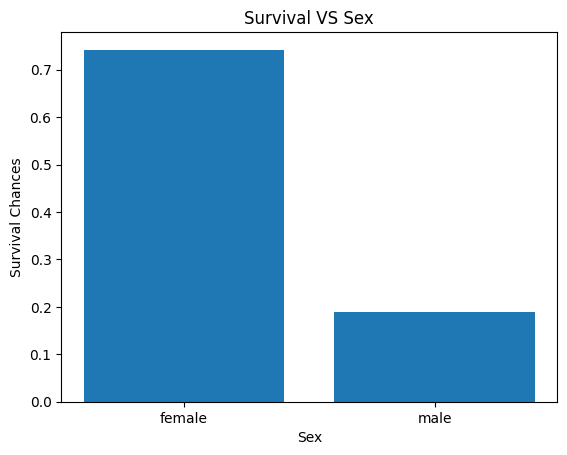

pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64


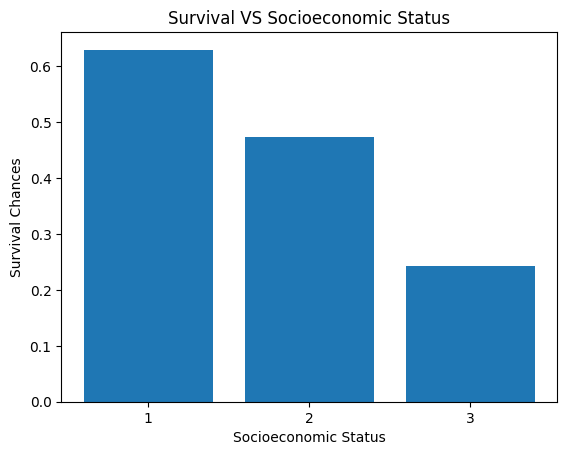

embarked
C    0.553571
Q    0.389610
S    0.336957
Name: survived, dtype: float64


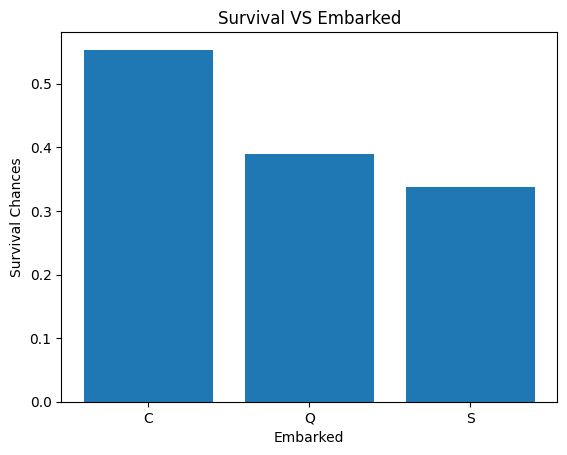

alone
False    0.505650
True     0.303538
Name: survived, dtype: float64


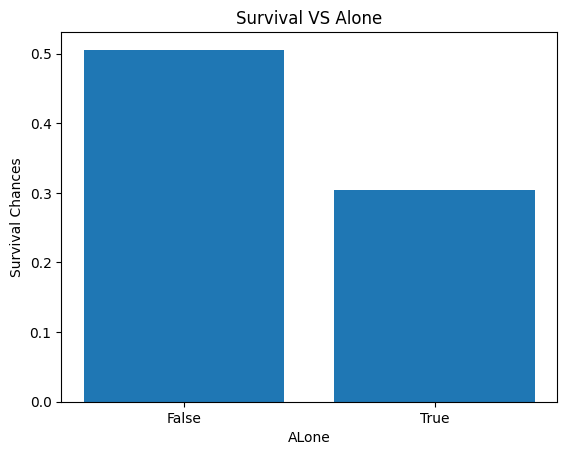

adult_male
False    0.717514
True     0.163873
Name: survived, dtype: float64


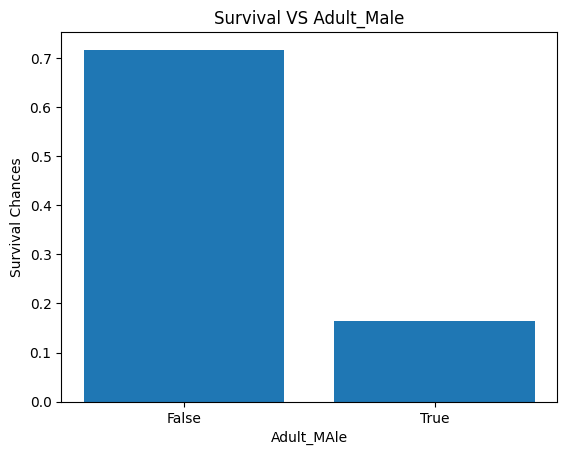

Fare Survival Means:
0-10 : 0.19940476190476192
10-50 : 0.4213197969543147
50-100 : 0.6481481481481481
100-600 : 0.7358490566037735


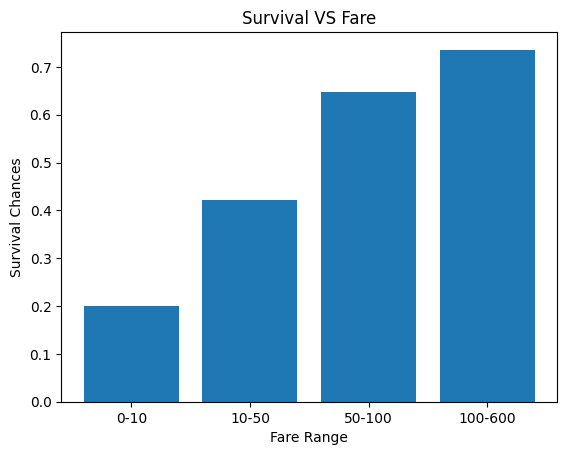

Age Survival Means:
0-20 : 0.4817073170731707
20-40 : 0.3875968992248062
40-60 : 0.39416058394160586
60-80 : 0.24
80-100 : 1.0


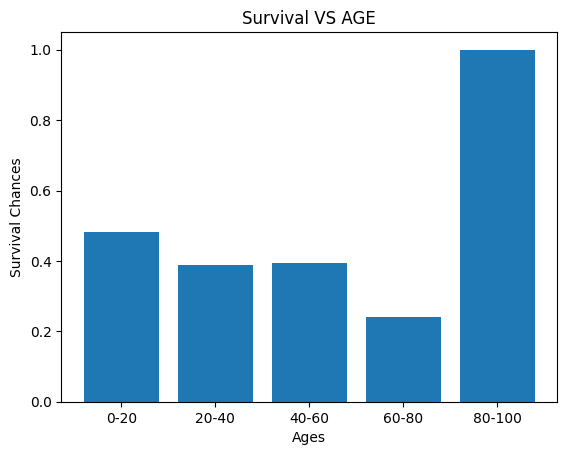

who
child    0.590361
man      0.163873
woman    0.756458
Name: survived, dtype: float64


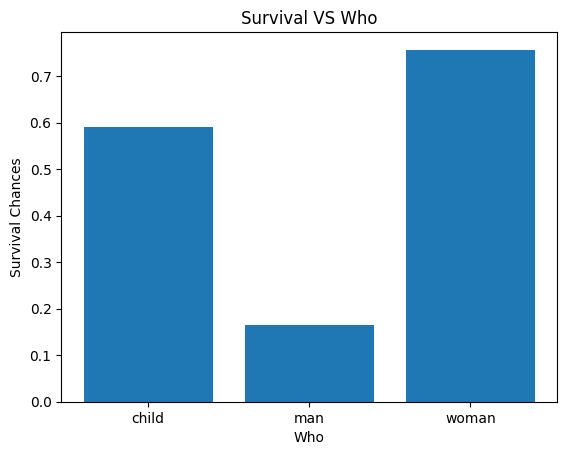

In [37]:
# TODO: Plot the mean survival rate for each categorical column listed above.
# Use df.groupby(col)['survived'].mean() and visualize comparable bars/subplots.
# Keep notes on which categories look the most/least promising.
survival_means= df.groupby('sex')['survived'].mean()
print(survival_means)
plt.bar(survival_means.index,survival_means.values)
plt.title("Survival VS Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Chances")
plt.show()

survival_means = df.groupby('pclass')['survived'].mean()
# print(survival_means.head())
print(survival_means)
plt.bar(survival_means.index.astype(str),survival_means.values)
plt.title("Survival VS Socioeconomic Status")
plt.xlabel("Socioeconomic Status")
plt.ylabel("Survival Chances")
plt.show()

survival_means = df.groupby('embarked')['survived'].mean()
# print(survival_means.head())
print(survival_means)
plt.bar(survival_means.index,survival_means.values)
plt.title("Survival VS Embarked")
plt.xlabel("Embarked")
plt.ylabel("Survival Chances")
plt.show()

survival_means = df.groupby('alone')['survived'].mean()
# print(survival_means.head())
print(survival_means)
plt.bar(survival_means.index.astype(str),survival_means.values)
plt.title("Survival VS Alone")
plt.xlabel("ALone")
plt.ylabel("Survival Chances")
plt.show()

survival_means = df.groupby('adult_male')['survived'].mean()
# print(survival_means.head())
print(survival_means)
plt.bar(survival_means.index.astype(str),survival_means.values)
plt.title("Survival VS Adult_Male")
plt.xlabel("Adult_MAle")
plt.ylabel("Survival Chances")
plt.show()

fare_ranges = [
    [0, 10],
    [10, 50],
    [50, 100],
    [100, 600]
]

range_labels = []
survival_values = []

for r in fare_ranges:
    low = r[0]
    high = r[1]
    group = df[(df['fare'] >= low) & (df['fare'] < high)]

    if len(group) > 0:
        mean_survival = group['survived'].mean()
    else:
        mean_survival = 0  
    range_labels.append(f"{low}-{high}")
    survival_values.append(mean_survival)

print("Fare Survival Means:")
for label, value in zip(range_labels, survival_values):
    print(label, ":", value)

plt.bar(range_labels, survival_values)
plt.title("Survival VS Fare")
plt.xlabel("Fare Range")
plt.ylabel("Survival Chances")
plt.show()

age_ranges = [
    [0, 20],
    [20, 40],
    [40, 60],
    [60, 80],
    [80, 100],
]

age_range_labels = []
age_survival_values = []

for r in age_ranges:
    low = r[0]
    high = r[1]
    group = df[(df['age'] >= low) & (df['age'] < high)]

    if len(group) > 0:
        age_mean_survival = group['survived'].mean()
    else:
        age_mean_survival = 0  
    age_range_labels.append(f"{low}-{high}")
    age_survival_values.append(age_mean_survival)

print("Age Survival Means:")
for label, value in zip(age_range_labels, age_survival_values):
    print(label, ":", value)

plt.bar(age_range_labels, age_survival_values)
plt.title("Survival VS AGE")
plt.xlabel("Ages")
plt.ylabel("Survival Chances")
plt.show()


survival_means = df.groupby('who')['survived'].mean()
# print(survival_means.head())
print(survival_means)
plt.bar(survival_means.index,survival_means.values)
plt.title("Survival VS Who")
plt.xlabel("Who")
plt.ylabel("Survival Chances")
plt.show()


### Part C.2 — Choose Features & Encode (10 Marks)
Now pick the columns that actually showed a survival pattern (clear correlation in Part C.1) and turn them into a tidy numeric matrix. When in doubt, keep the signal-rich basics (class, sex, age, siblings/spouses, parents/children, fare, embark).


**Guidance:**
- Target: `survived` (1 = survived, 0 = did not survive). Keep it as the final column for convenience.
- After reviewing the plots, pick base features such as `sex`, `age`, `sibsp`, `parch`, `fare`, `embarked`, `alone`, etc., and justify exclusions (e.g., leakage, redundancy, missingness).
- Handle missing values with simple, clearly stated strategies (drop rows, fill with median/mode, etc.).
- Use a concise one-hot encoder (e.g., `pd.get_dummies`) to turn categorical columns into numeric indicators.
- Maintain aligned `X` (features) and `y` (target) indices.





In [38]:
# TODO: Build a cleaned feature matrix informed by Part C.1.
# 1) Select final feature_cols + target, 2) handle missing values, 3) one-hot encode categoricals (pd.get_dummies).
# Return aligned X (encoded features), y (target), and a simplified df_tree for the scratch tree.
feature_cols = ['sex', 'fare', 'pclass', 'embarked', 'sibsp','parch','age']
df["age"].fillna(df["age"].median(), inplace=True)
df["fare"].fillna(df["fare"].median(), inplace=True)
df["embarked"].fillna(df["embarked"].mode()[0], inplace=True)

X = pd.get_dummies(df[feature_cols], drop_first=True)
y = df['survived'].loc[X.index]

X_Matrix = X.values
y_target = y.values
print("X shape:" , X.shape)
print("y shape:" , y.shape)
print("Feature columns:", list(X.columns))
print(X.head())
print(y.head())

X shape: (891, 8)
y shape: (891,)
Feature columns: ['fare', 'pclass', 'sibsp', 'parch', 'age', 'sex_male', 'embarked_Q', 'embarked_S']
      fare  pclass  sibsp  parch   age  sex_male  embarked_Q  embarked_S
0   7.2500       3      1      0  22.0      True       False        True
1  71.2833       1      1      0  38.0     False       False       False
2   7.9250       3      0      0  26.0     False       False        True
3  53.1000       1      1      0  35.0     False       False        True
4   8.0500       3      0      0  35.0      True       False        True
0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64


C:\Users\Muhammad Bilal\AppData\Local\Temp\ipykernel_20212\2135096447.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(df["age"].median(), inplace=True)
C:\Users\Muhammad Bilal\AppData\Local\Temp\ipykernel_20212\2135096447.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves

## Part D - Train/Test Split (5 Marks)
**Guidance:**
- Use the sklearn library to perform an 80/20 split on your data, saving 20% of it for testing and using 80% of it for training your model. 

**Deliverables:** shapes and class balance check (optional mean of `y`).

In [39]:
# TODO: Implement an 80/20 train/test split using sklearn.
# Use sklearn.model_selection.train_test_split with test_size=0.2 and a fixed random_state
# to ensure deterministic shuffling.
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split(X_Matrix,y_target,test_size=0.2,random_state=42)
print("X_train shape:" , X_train.shape)
print("X_test shape:" , X_test.shape)
print("y_train shape:" , y_train.shape)
print("y_test shape:" , y_test.shape)


X_train shape: (712, 8)
X_test shape: (179, 8)
y_train shape: (712,)
y_test shape: (179,)


## Part F - Decision Tree design from scratch (50 Marks)
**You must implement the core logic.** Below is a suggested structure. You may alter method signatures, add helpers, and use a different internal design if you prefer, but keep responsibilities clear:

- `Node`: stores split info (`feature`, `threshold`), children (`left`, `right`), and for leaves, a `classifier` (majority class) or distribution.
- `DecisionTree`: orchestrates fitting (`fit`), recursive tree building (`make_tree`), traversal for predictions (`traverse_tree`, `predict`), splitting (`best_split`, `split`), and impurity calculations (`calculate_entropy`, `calculate_information_gain`).

**Policy:**
- Use **entropy** as the impurity measure and **information gain** for splits.
- Only **binary splits** of the form `feature <= threshold`.
- Stopping criteria (minimum): `max_depth` reached **or** min_samples remaining **or** pure node (all labels identical) **or** no valid split (info gain ≤ 0).

The code below is a **skeleton**. Fill in the `TODO` parts. 

**BONUS:**
- You may add extra helper functions, or you may change the given function signatures as needed. If you add any extra features which allow for interesting functionality / interesting analysis down the line (you will have to show the analysis as well) - you get bonus marks. This bonus will not exceed the total number of marks allotted for the assignment.

In [40]:
import numpy as np

class Node:
    def __init__(self, left=None, right=None, feature=None, threshold=None, classifier=None):
        """Leaf nodes store a classifier label; internal nodes carry a feature+threshold."""
        self.left = left
        self.right = right
        self.feature = feature
        self.threshold = threshold
        self.classifier = classifier

    def is_leaf(self):
        """Convenience helper so you know when traversal should stop."""
        return self.classifier is not None

class DecisionTree:
    def __init__(self, max_depth=5, min_samples_split=5):
        """Store any hyperparameters you need (e.g., depth limit, feature indices)."""
        self.max_depth = max_depth
        self.min_samples = min_samples_split
        self.root = None

    def fit(self, Xy):
        """Build the tree recursively using the combined feature+label matrix."""
        self.n_features = Xy.shape[1] - 1
        self.root = self._make_tree(Xy, depth=0)

    def predict(self, X):
        """Traverse the learned tree row by row to produce class predictions."""
        preds = []
        for row in X:
            node = self.root
            while not node.is_leaf():
                if row[node.feature] <= node.threshold:
                    node = node.left
                else:
                    node = node.right
            
            preds.append(node.classifier)
        return np.array(preds)

    def _make_tree(self, Xy, depth):
        """Decide whether to stop (leaf) or split further based on stopping rules."""
        X = Xy[:, :-1]
        y = Xy[:, -1]
        n_samples = len(y)
        node = self.root
        if depth >= self.max_depth or n_samples < self.min_samples:
            zeros = list(y).count(0)
            ones = list(y).count(1)
            if ones >= zeros:
                majority = 1
            else:
                majority = 0

            return Node(classifier= majority)
        best_choice = self._best_split(Xy)
        if best_choice is None:
            zeros = list(y).count(0)
            ones = list(y).count(1)
            if ones >= zeros:
                majority = 1
            else:
                majority = 0

            return Node(classifier= majority)
        feature,threshold,IG = best_choice
        f_col = Xy[:,feature] 
        left_mask = (f_col <= threshold)
        right_mask = (f_col > threshold)
        if left_mask.any() == False or right_mask.any() == False:
            zeros = list(y).count(0)
            ones = list(y).count(1)
            if ones >= zeros:
                majority = 1
            else:
                majority = 0

            return Node(classifier= majority)
        left_matrix = Xy[left_mask]
        right_matrix = Xy[right_mask]
        left_node = self._make_tree(left_matrix, depth + 1)
        right_node = self._make_tree(right_matrix, depth + 1)

        return Node(left=left_node, right=right_node, feature=feature, threshold=threshold)

    def _best_split(self, Xy):
        """Search candidate thresholds per feature and return the best information gain."""
        X = Xy[:,:-1]
        y = Xy[:,-1]
        H_parent = self._entropy_of_data(y)
        num_samples , num_features = X.shape
        best_IG = -np.inf
        best_thr = None
        best_feature = None 
        for feature_idx in range(num_features):
            unique_vals = np.unique(X[:,feature_idx])
            thr = []
            for i in range(len(unique_vals) - 1):
                thr.append((unique_vals[i] + unique_vals[i + 1]) / 2)

            for threshold in thr:
                left_mask = (X[:,feature_idx] <= threshold)
                right_mask = (X[:,feature_idx] > threshold)
                if left_mask.any() == False or right_mask.any() == False:
                    continue
                left_vector = y[left_mask] # to get coreesponfing survival column
                right_vector = y[right_mask]
                IG = self._information_gain(H_parent,left_vector,right_vector)
                if IG > best_IG:
                    best_feature = feature_idx
                    best_IG = IG
                    best_thr = threshold
        
        if best_feature is None:
            return None
        return best_feature, best_thr, best_IG

    def _entropy_of_data(self, Xy):
        """Compute entropy of the target distribution for the provided rows."""
        count_1 = 0
        count_0 = 0
        label_column = Xy
        for label in label_column:
            if label == 1:
                count_1 += 1
            else:
                count_0 += 1

        total_num = count_0 + count_1
        if count_1 == 0 or count_0 == 0:
            return 0
        return((count_1/total_num) * np.log2(total_num/count_1) + count_0/total_num * np.log2(total_num/count_0))

    def _information_gain(self, parent_H, left, right):
        """IG = parent entropy minus weighted child entropy (useful for scoring splits)."""
        n_left = len(left)
        n_right = len(right)
        n = n_left + n_right
        H_weighted = (n_left/n) * self._entropy_of_data(left) + (n_right/n) * self._entropy_of_data(right)
        IG = parent_H - H_weighted
        return IG


## Part G - Exploring Max Depth(10 Marks)
**Instructions:**
- Instantiate your `DecisionTree` with a reasonable `max_depth` (e.g., 4–6) and `min_samples_split` (e.g., 2–5).
- Fit on `X_train, y_train`.
- Predict on `X_test`. Compute the standard metrics (accuracy, precision, recall, F1) and show the confusion matrix. Keep printouts clear and labeled.
- In a short markdown response below, comment on performance (3–5 lines).

In [41]:
# TODO: Instantiate your DecisionTree with chosen hyperparameters, fit on the training matrix, and generate predictions.
# Example: tree = DecisionTree(max_depth=...) ; tree.fit(train_matrix) ; y_pred = tree.predict(X_test_arr)
model = DecisionTree(max_depth=5, min_samples_split= 5)
train_matrix = np.concatenate((X_train, y_train.reshape(-1,1)), axis=1)
model.fit(train_matrix)
y_pred = model.predict(X_test)


In [42]:
# TODO: Compute accuracy/precision/recall/F1 (sklearn.metrics) to summarize performance.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.3f}")
print(f"F1 Score: {f1:.3f}")
print(f"Recall: {recall:.3f}")
print(f"Precision: {precision:.3f}")



Accuracy: 0.804
F1 Score: 0.737
Recall: 0.662
Precision: 0.831


Text(50.722222222222214, 0.5, 'True Label')

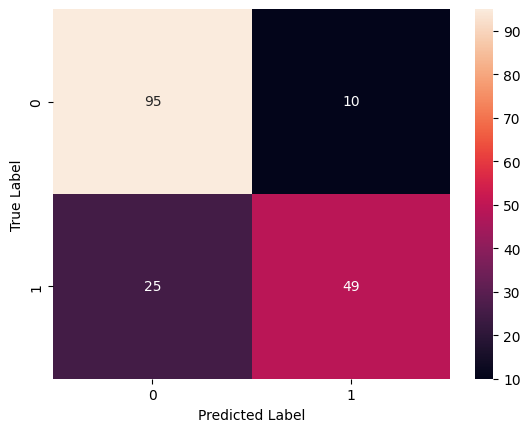

In [43]:
# TODO: Build and visualize a confusion matrix using sklearn.metrics.confusion_matrix + seaborn/matplotlib.
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')            


**Performance notes:**  
- TODO: Briefly discuss overall performance and the balance of precision/recall. Suggest one parameter you would tune to vary results and why (e.g., `max_depth`, `min_samples_split`, or using probabilities with a threshold).

From the scores we can see that the model has a high precision which means that the model more generally accurately predicts a person surviving.We can see that the recall(0.662) and from the confusion matrix thera are 49 true positives and 25 false negatives thus showing it finds a good amount of actual survivors. The model predicts a person not surviving more often and but when it does predicts survival it is accurate most of the times.

We can tune max_depth by increasing the depth such that there are more splits and leaf nodes at the end ,thus more pure leafs. This would improve recall and model would be able to capture more complex patterns.



#### **Assume** that your model gives an Accuracy of ~60%. What could be the most probable explanation for this specific number? Make sure to use code to explain your answer. 

In [44]:
# Hint: Inspect class imbalance in the training set.
count_0 = 0
count_1 = 0
for y in y_train:
    if y == 0:
        count_0 += 1
    else:
        count_1 += 1
print(f"Not Surviving percerntage: {count_0/(count_0 + count_1):.3f}")
print(f"Surviving percerntage: {count_1/(count_0 + count_1):.3f}")

Not Surviving percerntage: 0.624
Surviving percerntage: 0.376


Since the people do not survive more often there is a large class imbalance thus making it harder to learn pattern of the smaller classof survivors.Increasing the tree depth gives the model more chances to split the two classes and create purer leafs

## Part H - Different Max depth values (10 Marks)

After seeing how our initial model performed with a default value of Max depth , we will now explore different Max depth values. This step will help us find the best Max depth setting to improve our model's ability to predict accurately

- Gather the accuracy for each `max_depth` value on the test set and compare them. Show these comparisons in a graph to easily see which `max_depth` value leads to the best predictions. This will help us choose the best k value for our model.


In [45]:
# TODO: Loop over multiple max_depth values, train fresh trees, and store their accuracies.
# This helps visualize how model complexity affects generalization.
max_depths = [ i for i in range(1,30)]
accuracies = []
best_depth = None
best_acc = -np.inf
best_prec = -np.inf
best_f1 = -np.inf
best_r= -np.inf
for depth in max_depths:
    model = DecisionTree(max_depth=depth, min_samples_split=5)
    train_matrix = np.concatenate((X_train, y_train.reshape(-1,1)), axis=1)
    model.fit(train_matrix)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    accuracies.append(acc)
    if(acc > best_acc):
        best_acc = acc
        best_depth = depth
        best_prec = precision
        best_f1 = f1
        best_r = recall

print(f"Best Depth(k): {best_depth}")
print(f"Best Accuracy: {best_acc:.3f}")
print(f"Best precision: {best_prec:.3f}")
print(f"Best recall: {best_r:.3f}")
print(f"Best f1: {best_f1:.3f}")


Best Depth(k): 9
Best Accuracy: 0.827
Best precision: 0.841
Best recall: 0.716
Best f1: 0.774


Text(0.5, 1.0, 'ACCURACY VS MAX-DEPTH')

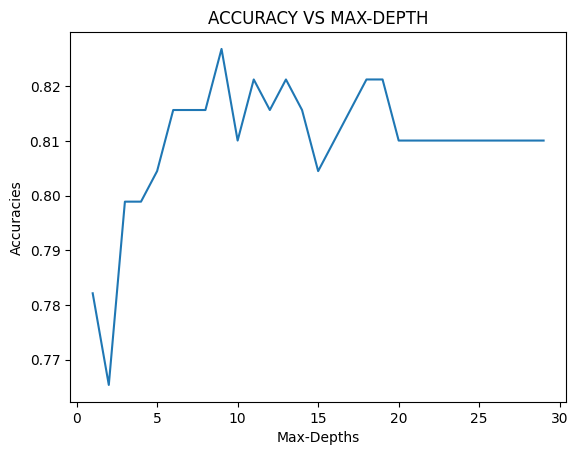

In [46]:
# TODO: Plot accuracy vs. max_depth using matplotlib so you can discuss the trend.
plt.plot(max_depths,accuracies)
plt.xlabel("Max-Depths")
plt.ylabel("Accuracies")
plt.title("ACCURACY VS MAX-DEPTH")


### What are you able to determine through the trend obtained for accuracy as depth varies? (5 Marks)

_Summarize your conclusion (e.g., overfitting/underfitting) after inspecting the accuracy-vs-depth plot._

Generally an increase is seen in the accuracy of our model as the max_depth increases until it plateus at the end meaning that after our best possible max_depth(k = 9) it becomes impossible for the leaf nodes to become any purer.So increasing any more depth does not increase the performance and we get the best accuracy of 0.827.
A huge dip in accuracy is also seen in the graph which may be due to the model fitting to the noise in the data(overfitting at those depths).

